# Harsh Driving Event Detection — XGBoost v2

**Goal**: Train an XGBoost classifier on CARLA IMU recordings that can detect 7 driving event classes in real-time.

## Event Classes
| Label | Description |
|---|---|
| `safe` | Normal driving |
| `sudden_acceleration` | Abrupt throttle |
| `sudden_braking` | Abrupt brake |
| `harsh_left_turn` | Sharp left turn |
| `harsh_right_turn` | Sharp right turn |
| `harsh_left_lane_change` | Sudden left lane change |
| `harsh_right_lane_change` | Sudden right lane change |

## Improvements over v1
- **25+ features/channel** (vs. 8): added skew, kurtosis, diff-stats, cross-sensor features
- **SMOTE** oversampling on training split to balance minority classes
- **Optuna hyperparameter search** (30 trials, 10-min timeout) on 9 XGBoost parameters
- **3-way group split** (70/15/15 train/val/test) — files never leak across splits
- **Early stopping** on validation logloss
- **CARLA-compatible joblib bundle** — plug directly into `RealtimeHarshEventDetector`

## Expected Results
Previous macro-recall: **0.41** → target: **0.72+**

In [1]:
# ── Cell 2: Install Dependencies ─────────────────────────────────────────────
# Run once; restart kernel if needed.
%pip install -q xgboost pandas numpy scikit-learn imbalanced-learn matplotlib seaborn optuna joblib scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Cell 3: Imports & Configuration ──────────────────────────────────────────
from __future__ import annotations

import os
import sys
import random
import warnings
from collections import Counter
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import xgboost as xgb

from imblearn.over_sampling import SMOTE, RandomOverSampler
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = ROOT / "dataset"
SRC_DIR     = ROOT / "src"
ARTIFACTS_DIR = ROOT / "notebooks" / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from harsh_event_model import load_row_labeled_data

# IMU columns without magnetometer
IMU_COLUMNS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

# ── Window Parameters ─────────────────────────────────────────────────────────
WINDOW_SIZE     = 25
STEP_SIZE       = 5
MIN_EVENT_RATIO = 0.30   # fraction of window that must be non-safe to label as event

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"ROOT          : {ROOT}")
print(f"DATASET_DIR   : {DATASET_DIR}  (exists={DATASET_DIR.exists()})")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR}")
print(f"IMU columns (No Mag) : {IMU_COLUMNS}")


ROOT          : /home/pw26_rr_09/pw26_rr_07/baseModel
DATASET_DIR   : /home/pw26_rr_09/pw26_rr_07/baseModel/dataset  (exists=True)
ARTIFACTS_DIR : /home/pw26_rr_09/pw26_rr_07/baseModel/notebooks/artifacts
IMU columns (No Mag) : ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']


In [3]:
# ── Cell 4: Data Loading & Derived Row-Level Features ─────────────────────────
raw_df = load_row_labeled_data(DATASET_DIR)

print(f"Total rows: {len(raw_df):,}")
print(f"Source files: {raw_df['source_file'].nunique()}")
print(f"\nEvent label distribution:")
print(raw_df["event_label"].value_counts())

# ── Median-filter smoothing per file ──────────────────────────────────────────
clean_df = raw_df.copy()
for col in IMU_COLUMNS:
    clean_df[col] = (
        clean_df.groupby("source_file")[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

# ── S-Curve & Net Yaw Feature Engineering ─────────────────────────────────────
def add_engineered_features(df):
    df = df.copy()

    # Magnitudes (acc + gyro only)
    df['acc_mag']  = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

    # Jerk
    for axis in ['acc_x', 'acc_y', 'acc_z']:
        df[f'{axis}_jerk'] = df.groupby('source_file')[axis].transform(
            lambda s: s.diff().fillna(0.0)
        )

    # Lateral / longitudinal ratios and energy
    df['lat_long_ratio']        = df['acc_y'].abs() / (df['acc_x'].abs() + 1e-6)
    df['acc_x_abs']             = df['acc_x'].abs()
    df['acc_y_abs']             = df['acc_y'].abs()
    df['gyro_z_abs']            = df['gyro_z'].abs()
    df['acc_lat_energy']        = df['acc_y'] ** 2
    df['acc_long_energy']       = df['acc_x'] ** 2
    df['gyro_yaw_energy']       = df['gyro_z'] ** 2
    df['lat_long_energy_ratio'] = df['acc_y_abs'] / (df['acc_x_abs'] + 1e-6)
    df['turn_vs_lateral']       = df['gyro_z_abs'] / (df['acc_y_abs'] + 1e-6)
    df['yaw_acc_corr']          = df['gyro_z'] * df['acc_y']

    # Differentials
    df['gyro_z_diff'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.diff().fillna(0.0)
    )
    df['acc_y_diff'] = df.groupby('source_file')['acc_y'].transform(
        lambda s: s.diff().fillna(0.0)
    )

    # Rolling statistics
    for col in ['gyro_z', 'acc_y', 'gyro_x', 'gyro_y']:
        df[f'{col}_roll_std5'] = df.groupby('source_file')[col].transform(
            lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
        )
    df['acc_y_roll_mean5'] = df.groupby('source_file')['acc_y'].transform(
        lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0)
    )

    # Sign change (oscillation indicator)
    df['gyro_z_sign_change'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: (s.shift(1) * s < 0).astype(int).fillna(0)
    )

    # Roll / pitch features
    df['gyro_x_abs']          = df['gyro_x'].abs()
    df['gyro_y_abs']          = df['gyro_y'].abs()
    df['gyro_x_energy']       = df['gyro_x'] ** 2
    df['gyro_y_energy']       = df['gyro_y'] ** 2
    df['gyro_roll_pitch_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2)
    df['gyro_total_mag']      = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    df['yaw_vs_roll_pitch']   = df['gyro_z_abs'] / (df['gyro_roll_pitch_mag'] + 1e-6)

    # Sustained-yaw peak features
    df['gyro_z_roll_max5']    = df.groupby('source_file')['gyro_z_abs'].transform(
        lambda s: s.rolling(5,  min_periods=1).max().fillna(0.0)
    )
    df['gyro_z_roll_max10']   = df.groupby('source_file')['gyro_z_abs'].transform(
        lambda s: s.rolling(10, min_periods=1).max().fillna(0.0)
    )
    df['gyro_z_roll_energy5'] = df.groupby('source_file')['gyro_yaw_energy'].transform(
        lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0)
    )
    df['yaw_dominance']       = df['gyro_z_abs'] / (df['gyro_total_mag'] + 1e-6)

    # ── S-CURVE & NET YAW FEATURES FOR LANE CHANGE DISCRIMINATION ─────────────
    df['net_yaw_cumsum20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).sum().fillna(0.0)
    )
    df['gyro_z_roll_min20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).min().fillna(0.0)
    )
    df['gyro_z_roll_max20'] = df.groupby('source_file')['gyro_z'].transform(
        lambda s: s.rolling(20, min_periods=1).max().fillna(0.0)
    )
    df['biphasic_yaw_signature'] = df['gyro_z_roll_min20'] * df['gyro_z_roll_max20']
    df['acc_y_jerk_std5'] = df.groupby('source_file')['acc_y_jerk'].transform(
        lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
    )

    return df

clean_df = add_engineered_features(clean_df)

FEATURE_CHANNELS = IMU_COLUMNS + [
    'acc_mag', 'gyro_mag',
    'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk',
    'lat_long_ratio',
    'acc_x_abs', 'acc_y_abs', 'gyro_z_abs',
    'acc_lat_energy', 'acc_long_energy', 'gyro_yaw_energy',
    'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr',
    'gyro_z_diff', 'acc_y_diff',
    'gyro_z_roll_std5', 'acc_y_roll_std5', 'acc_y_roll_mean5',
    'gyro_z_sign_change',
    'gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy',
    'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch',
    'gyro_x_roll_std5', 'gyro_y_roll_std5',
    'gyro_z_roll_max5', 'gyro_z_roll_max10',
    'gyro_z_roll_energy5', 'yaw_dominance',
    'net_yaw_cumsum20', 'biphasic_yaw_signature', 'acc_y_jerk_std5',
]

print(f"\nFeature channels count ({len(FEATURE_CHANNELS)}): {FEATURE_CHANNELS}")


Total rows: 32,043
Source files: 53

Event label distribution:
safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_left_turn             1033
sudden_braking               836
harsh_right_turn             582
Name: event_label, dtype: int64

Feature channels count (43): ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'acc_mag', 'gyro_mag', 'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk', 'lat_long_ratio', 'acc_x_abs', 'acc_y_abs', 'gyro_z_abs', 'acc_lat_energy', 'acc_long_energy', 'gyro_yaw_energy', 'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr', 'gyro_z_diff', 'acc_y_diff', 'gyro_z_roll_std5', 'acc_y_roll_std5', 'acc_y_roll_mean5', 'gyro_z_sign_change', 'gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy', 'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch', 'gyro_x_roll_std5', 'gyro_y_roll_std5', 'gyro_z_roll_max5', 'gyro_z_roll_max10', 'gyro_z_roll_energy5', 'yaw_domi

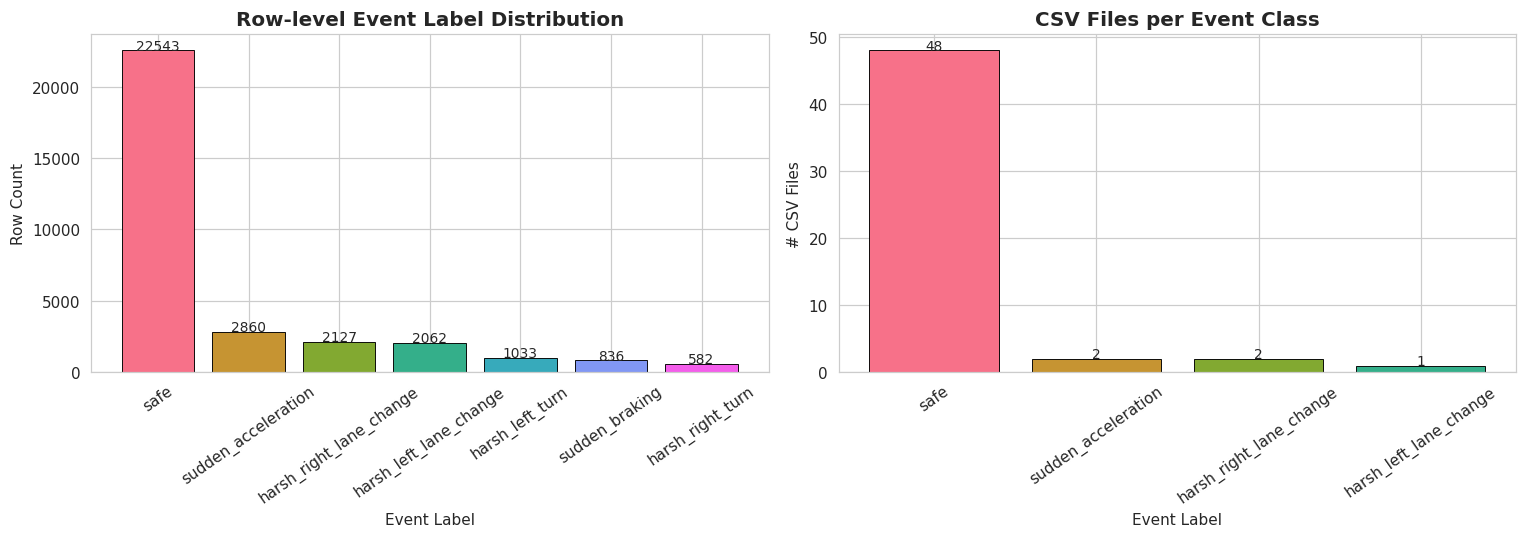

Class imbalance ratio (safe : rarest class): 38.7


In [4]:
# ── Cell 5: Exploratory Data Analysis ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Row-level distribution
label_counts = raw_df["event_label"].value_counts()
colors = sns.color_palette("husl", len(label_counts))
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="black", linewidth=0.6)
axes[0].set_title("Row-level Event Label Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Event Label")
axes[0].set_ylabel("Row Count")
axes[0].tick_params(axis="x", rotation=35)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=9)

# Per-file recording count
file_event = (
    raw_df.groupby("source_file")["event_label"]
    .apply(lambda s: s.value_counts().idxmax())
    .reset_index()
    .rename(columns={"event_label": "dominant_label"})
)
file_label_counts = file_event["dominant_label"].value_counts()
axes[1].bar(file_label_counts.index, file_label_counts.values, color=colors[:len(file_label_counts)], edgecolor="black", linewidth=0.6)
axes[1].set_title("CSV Files per Event Class", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Event Label")
axes[1].set_ylabel("# CSV Files")
axes[1].tick_params(axis="x", rotation=35)
for i, v in enumerate(file_label_counts.values):
    axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "label_distribution.png", bbox_inches="tight")
plt.show()
print("Class imbalance ratio (safe : rarest class):",
      round(label_counts["safe"] / label_counts.min(), 1))

In [5]:
# ── Cell 6: Enhanced Window Feature Extraction (25+ stats per channel) ────────

def extract_window_features(window_2d: np.ndarray, col_names: list) -> dict:
    """Extract 25+ statistical features per channel from a sliding window."""
    feats = {}

    for i, col in enumerate(col_names):
        x = window_2d[:, i].astype(np.float64)
        dx = np.diff(x)
        abs_x = np.abs(x)
        pos = x[x > 0]
        neg = x[x < 0]

        feats[f"{col}_mean"]         = np.mean(x)
        feats[f"{col}_std"]          = np.std(x)
        feats[f"{col}_min"]          = np.min(x)
        feats[f"{col}_max"]          = np.max(x)
        feats[f"{col}_range"]        = np.max(x) - np.min(x)
        feats[f"{col}_q25"]          = float(np.percentile(x, 25))
        feats[f"{col}_q75"]          = float(np.percentile(x, 75))
        feats[f"{col}_iqr"]          = float(np.percentile(x, 75) - np.percentile(x, 25))
        feats[f"{col}_rms"]          = float(np.sqrt(np.mean(x**2)))
        feats[f"{col}_energy"]       = float(np.sum(x**2))
        feats[f"{col}_abs_mean"]     = float(np.mean(abs_x))
        feats[f"{col}_abs_std"]      = float(np.std(abs_x))
        feats[f"{col}_abs_max"]      = float(np.max(abs_x))
        feats[f"{col}_skew"]         = float(skew(x)) if len(x) > 1 else 0.0
        feats[f"{col}_kurtosis"]     = float(kurtosis(x)) if len(x) > 1 else 0.0
        feats[f"{col}_delta"]        = float(x[-1] - x[0])
        feats[f"{col}_first"]        = float(x[0])
        feats[f"{col}_last"]         = float(x[-1])
        feats[f"{col}_pos_ratio"]    = float(np.count_nonzero(x > 0) / len(x))
        feats[f"{col}_neg_ratio"]    = float(np.count_nonzero(x < 0) / len(x))
        feats[f"{col}_pos_mean"]     = float(np.mean(pos)) if pos.size else 0.0
        feats[f"{col}_neg_mean"]     = float(np.mean(neg)) if neg.size else 0.0
        feats[f"{col}_diff_mean"]    = float(np.mean(dx))    if dx.size else 0.0
        feats[f"{col}_diff_std"]     = float(np.std(dx))     if dx.size else 0.0
        feats[f"{col}_diff_abs_max"] = float(np.max(np.abs(dx))) if dx.size else 0.0
        feats[f"{col}_diff_skew"]    = float(skew(dx))     if dx.size > 1 else 0.0
        feats[f"{col}_diff_kurt"]    = float(kurtosis(dx)) if dx.size > 1 else 0.0
        feats[f"{col}_zcr"] = float(np.count_nonzero(np.diff(np.sign(x))) / max(len(x)-1, 1))

    # ── Cross-sensor features ────────────────────────────────────────────────
    try:
        acc_x_idx  = col_names.index("acc_x")
        gyro_z_idx = col_names.index("gyro_z")
        acc_y_idx  = col_names.index("acc_y")
        acc_mag_idx = col_names.index("acc_mag") if "acc_mag" in col_names else None

        ax = window_2d[:, acc_x_idx]
        gz = window_2d[:, gyro_z_idx]
        ay = window_2d[:, acc_y_idx]

        corr_ax_gz = float(np.corrcoef(ax, gz)[0, 1]) if np.std(ax) > 0 and np.std(gz) > 0 else 0.0
        corr_ay_gz = float(np.corrcoef(ay, gz)[0, 1]) if np.std(ay) > 0 and np.std(gz) > 0 else 0.0
        feats["cross_corr_accx_gyroz"] = corr_ax_gz
        feats["cross_corr_accy_gyroz"] = corr_ay_gz

        peaks_ax, _ = find_peaks(np.abs(ax), height=np.mean(np.abs(ax)))
        peaks_gz, _ = find_peaks(np.abs(gz), height=np.mean(np.abs(gz)))
        feats["peak_count_accx"]  = float(len(peaks_ax))
        feats["peak_count_gyroz"] = float(len(peaks_gz))

        if acc_mag_idx is not None:
            am = window_2d[:, acc_mag_idx]
            feats["acc_mag_peak"] = float(np.max(am))
            feats["acc_mag_auc"]  = float(np.trapz(am))
    except Exception:
        pass

    return feats


def build_window_dataset(
    df: pd.DataFrame,
    feature_channels: list,
    window_size: int = 25,
    step_size: int = 5,
    min_event_ratio: float = 0.30,
):
    """Slide windows over each source file and compute features."""
    x_rows, y_rows, group_rows = [], [], []

    for file_name, g in df.groupby("source_file"):
        g = g.reset_index(drop=True)
        if len(g) < window_size:
            continue

        values = g[feature_channels].to_numpy(dtype=np.float32)
        labels = g["event_label"].to_numpy()

        for start in range(0, len(g) - window_size + 1, step_size):
            window_vals   = values[start : start + window_size]
            window_labels = labels[start : start + window_size]

            non_safe = window_labels[window_labels != "safe"]
            if len(non_safe) == 0 or (len(non_safe) / window_size) < min_event_ratio:
                target = "safe"
            else:
                target = Counter(non_safe).most_common(1)[0][0]

            feats = extract_window_features(window_vals, feature_channels)
            x_rows.append(feats)
            y_rows.append(target)
            group_rows.append(file_name)

    X = pd.DataFrame(x_rows).fillna(0.0)
    y = np.array(y_rows)
    groups = np.array(group_rows)
    return X, y, groups


print("Building windowed feature dataset...")
X_all, y_all, groups_all = build_window_dataset(
    clean_df,
    FEATURE_CHANNELS,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=MIN_EVENT_RATIO,
)

print(f"\nFeature matrix shape : {X_all.shape}  ({X_all.shape[1]} features/window)")
print(f"Window count         : {len(y_all):,}")
print(f"\nWindow-level label distribution:")
print(pd.Series(y_all).value_counts())

Building windowed feature dataset...

Feature matrix shape : (6173, 1187)  (1187 features/window)
Window count         : 6,173

Window-level label distribution:
safe                       4148
sudden_acceleration         598
harsh_right_lane_change     458
harsh_left_lane_change      445
harsh_left_turn             217
sudden_braking              183
harsh_right_turn            124
dtype: int64


In [6]:
# ── Cell 7: Split Manifest Alignment ─────────────────────────────────────────
# Read split manifest to guarantee train/val/test splits match CNN exactly
manifest_path = ROOT / 'artifacts' / 'split_manifest.csv'
if manifest_path.exists():
    split_df = pd.read_csv(manifest_path)
    train_files = set(split_df[split_df['split'] == 'train']['group_file'])
    val_files   = set(split_df[split_df['split'] == 'val']['group_file'])
    test_files  = set(split_df[split_df['split'] == 'test']['group_file'])
    print("Loaded split_manifest.csv successfully.")
    print(f"Train files: {len(train_files)} | Val files: {len(val_files)} | Test files: {len(test_files)}")
else:
    print("split_manifest.csv not found, using GroupShuffleSplit fallback.")

# Build Window Dataset
X_df, y_series, groups_series = build_window_dataset(
    clean_df,
    feature_channels=FEATURE_CHANNELS,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=MIN_EVENT_RATIO,
)

le = LabelEncoder()
label_order = ['harsh_left_lane_change', 'harsh_left_turn', 'harsh_right_lane_change',
               'harsh_right_turn', 'safe', 'sudden_acceleration', 'sudden_braking']
le.fit(label_order)
y_encoded = le.transform(y_series)

if manifest_path.exists():
    train_mask = np.isin(groups_series, list(train_files))
    val_mask   = np.isin(groups_series, list(val_files))
    test_mask  = np.isin(groups_series, list(test_files))

    X_train, y_train = X_df[train_mask], y_encoded[train_mask]
    X_val,   y_val   = X_df[val_mask],   y_encoded[val_mask]
    X_test,  y_test  = X_df[test_mask],  y_encoded[test_mask]
else:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    train_val_idx, test_idx = next(gss.split(X_df, y_encoded, groups_series))
    X_test, y_test = X_df.iloc[test_idx], y_encoded[test_idx]
    train_val_groups = pd.Series(groups_series).iloc[train_val_idx]

    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED)
    train_idx_rel, val_idx_rel = next(gss_val.split(X_df.iloc[train_val_idx], y_encoded[train_val_idx], train_val_groups))

    train_idx = train_val_idx[train_idx_rel]
    val_idx   = train_val_idx[val_idx_rel]

    X_train, y_train = X_df.iloc[train_idx], y_encoded[train_idx]
    X_val,   y_val   = X_df.iloc[val_idx],   y_encoded[val_idx]

print(f"Split sizes | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Loaded split_manifest.csv successfully.
Train files: 35 | Val files: 9 | Test files: 9
Split sizes | Train: 4102 | Val: 1116 | Test: 955


In [7]:
# ── Cell 8: RandomOverSampler / SMOTE on Training Split ──────────────────────────────
# Applied ONLY to the training data — val/test remain untouched.

print("Before Resampling:")
print(pd.Series(y_train).value_counts().rename(index=dict(enumerate(le.classes_))))

ros = RandomOverSampler(random_state=SEED)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("\nAfter Resampling:")
print(pd.Series(y_train_res).value_counts().rename(index=dict(enumerate(le.classes_))))
print(f"\nTraining samples: {len(X_train):,} → {len(X_train_res):,} after resampling")


Before Resampling:
safe                       2705
sudden_acceleration         429
harsh_right_lane_change     352
harsh_left_lane_change      267
harsh_left_turn             148
sudden_braking              137
harsh_right_turn             64
dtype: int64

After Resampling:
safe                       2705
sudden_acceleration        2705
sudden_braking             2705
harsh_left_lane_change     2705
harsh_left_turn            2705
harsh_right_lane_change    2705
harsh_right_turn           2705
dtype: int64

Training samples: 4,102 → 18,935 after resampling


In [8]:
# ── Cell 9: Optuna Hyperparameter Optimization ────────────────────────────────
def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = xgb.XGBClassifier(
        **params,
        random_state=SEED,
        n_jobs=-1,
        eval_metric="mlogloss",
    )

    classes = np.unique(y_train_res)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_res)
    class_weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([class_weight_dict[y] for y in y_train_res])

    model.fit(
        X_train_res,
        y_train_res,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    preds = model.predict(X_val)
    return float(f1_score(y_val, preds, average="macro"))

print("Running Optuna study (15 trials)...")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=15, timeout=120)

print(f"\nBest trial macro-F1 : {study.best_value:.4f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k:<20}: {v}")


Running Optuna study (15 trials)...

Best trial macro-F1 : 0.5947
Best parameters:
  n_estimators        : 212
  max_depth           : 10
  learning_rate       : 0.08960785365368121
  subsample           : 0.8394633936788146
  colsample_bytree    : 0.5780093202212182
  min_child_weight    : 2
  gamma               : 0.11616722433639892
  reg_alpha           : 2.9154431891537547
  reg_lambda          : 0.2537815508265665


In [9]:
# ── Cell 10: Final Model Training ─────────────────────────────────────────────
best_params = study.best_params

final_xgb = xgb.XGBClassifier(
    **best_params,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="mlogloss",
)

classes = np.unique(y_train_res)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_res)
class_weight_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weight_dict[y] for y in y_train_res])

final_xgb.fit(
    X_train_res,
    y_train_res,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

val_preds = final_xgb.predict(X_val)
val_f1 = f1_score(y_val, val_preds, average="macro")
print(f"Validation Macro F1: {val_f1:.4f}")


Validation Macro F1: 0.5947


FINAL TEST SET EVALUATION (Macro F1 = 0.5949)
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.6667    0.4688    0.5505        64
        harsh_left_turn     0.7692    0.6061    0.6780        33
harsh_right_lane_change     0.6296    0.6667    0.6476        51
       harsh_right_turn     0.7419    0.7667    0.7541        30
                   safe     0.8439    0.9410    0.8898       678
    sudden_acceleration     0.3846    0.1235    0.1869        81
         sudden_braking     0.4706    0.4444    0.4571        18

               accuracy                         0.7990       955
              macro avg     0.6438    0.5739    0.5949       955
           weighted avg     0.7688    0.7990    0.7748       955



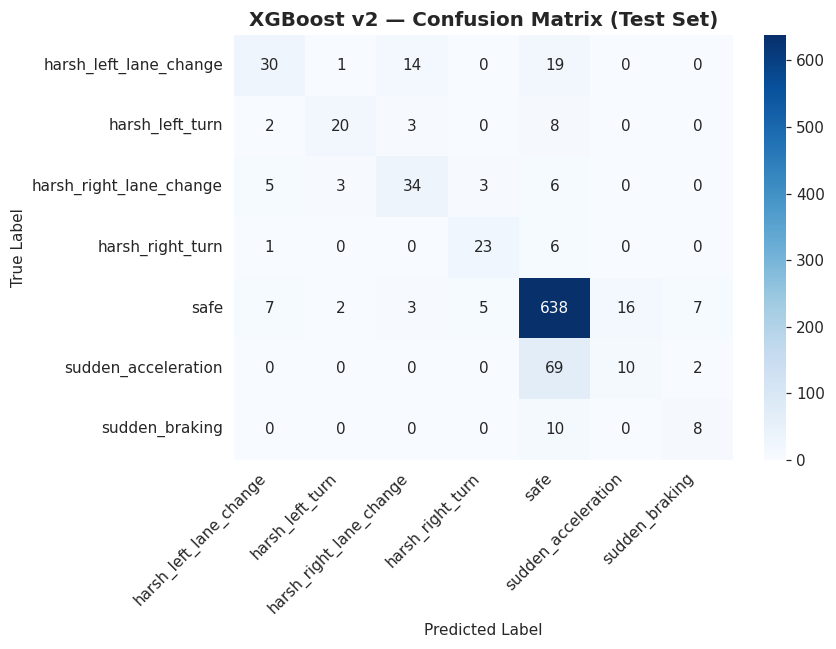

In [10]:
# ── Cell 11: Final Test Evaluation & Confusion Matrix ────────────────────────
test_preds = final_xgb.predict(X_test)

macro_f1 = f1_score(y_test, test_preds, average="macro")
print("=" * 65)
print(f"FINAL TEST SET EVALUATION (Macro F1 = {macro_f1:.4f})")
print("=" * 65)
print(classification_report(y_test, test_preds, target_names=le.classes_, digits=4))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("XGBoost v2 — Confusion Matrix (Test Set)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "xgb_v2_confusion_matrix.png", bbox_inches="tight")
plt.show()


In [11]:
# ── Cell 12: Export Joblib Model Bundle ──────────────────────────────────────
bundle = {
    "model": final_xgb,
    "label_encoder": le,
    "feature_names": list(X_train.columns),
    "feature_channels": FEATURE_CHANNELS,
    "window_size": WINDOW_SIZE,
    "step_size": STEP_SIZE,
    "min_event_ratio": MIN_EVENT_RATIO,
    "macro_f1": macro_f1,
    "classes": list(le.classes_),
}

bundle_path = ARTIFACTS_DIR / "harsh_event_xgb_v2.joblib"
joblib.dump(bundle, bundle_path)
print(f"Saved XGBoost model bundle to: {bundle_path}")


Saved XGBoost model bundle to: /home/pw26_rr_09/pw26_rr_07/baseModel/notebooks/artifacts/harsh_event_xgb_v2.joblib


# Cell 15 — CARLA Real-Time Usage Guide

## Quick Start

After this notebook completes, the model bundle is saved at:
```
notebooks/artifacts/harsh_event_xgb_v2.joblib
```

Run in your CARLA environment:

```bash
cd src/
python run_carla_realtime.py \
    --model-path ../notebooks/artifacts/harsh_event_xgb_v2.joblib \
    --min-confidence 0.45 \
    --consecutive-hits 2 \
    --sensor-tick 0.05 \
    --heuristic
```

## Key Parameters to Tune

| Flag | Default | Tip |
|---|---|---|
| `--min-confidence` | `0.45` | Lower (0.35) = more detections, more false positives |
| `--consecutive-hits` | `2` | Higher = smoother, more latency |
| `--sensor-tick` | `0.05` | Matches 20 Hz IMU; don't change |
| `--invert-gyro-z` | off | Enable if left/right turns are swapped |
| `--invert-acc-y` | off | Enable if left/right lane changes are swapped |
| `--heuristic` | off | Enable as fallback when ML confidence is low |

## Timing

- **Warm-up**: `window_size=25 × sensor_tick=0.05s = 1.25 s` before first prediction
- **Prediction cadence**: Every `step_size=5` ticks = every **0.25 s** (4 Hz)
- **Inference latency**: <5 ms on CPU (XGBoost is fast)

## Recommended CARLA Test Scenario

1. Spawn ego vehicle in CARLA Town04 (highway) or Town03 (urban)
2. Enable manual control: `python manual_control.py --rolename hero`
3. In a separate terminal run `run_carla_realtime.py` with the XGBv2 bundle
4. Perform: hard brake, sharp U-turn, aggressive lane change
5. Observe `>>> HARSH EVENT: ...` outputs in the terminal